In [180]:
import pandas as pd
import numpy as np

### Data Understanding

In [181]:
df = pd.read_csv('GoogleAds_DataAnalytics_Sales_Uncleaned.csv')
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


In [182]:
df.shape

(2600, 13)

In [183]:
df.columns

Index(['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads',
       'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location',
       'Device', 'Keyword'],
      dtype='object')

In [184]:
df.describe()

,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


In [185]:
df.dtypes

Ad_ID               object
Campaign_Name       object
Clicks             float64
Impressions        float64
Cost                object
Leads              float64
Conversions        float64
Conversion Rate    float64
Sale_Amount         object
Ad_Date             object
Location            object
Device              object
Keyword             object
dtype: object

### Data Preparation - Data Cleaning

In [186]:
""" 2. Currency Normalization (String to Float)
Problem: 'Cost' and 'Sale_Amount' are strings with '$' and ',' which prevents math.
Solution: Remove symbols and convert to numeric types."""
for col in ['Cost', 'Sale_Amount']:
    df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Dan\AppData\Local\Temp\ipykernel_4532\2375808005.py:5: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)


In [187]:
""" 3. Categorical Deduplication (Fixing Typos)
Problem: "Data Anlytics Corse" and "DataAnalyticsCourse" are the same thing.
Solution: Use a mapping dictionary to consolidate variants."""
campaign_map = {
    'DataAnalyticsCourse': 'Data Analytics Course',
    'Data Anlytics Corse': 'Data Analytics Course',
    'Data Analytcis Course': 'Data Analytics Course',
    'DataAnalytics Course': 'Data Analytics Course'
}
df['Campaign_Name'] = df['Campaign_Name'].replace(campaign_map)

In [188]:
# Fix Location typos and case sensitivity (e.g., 'hyderabad' vs 'HYDERABAD')
df['Location'] = df['Location'].str.strip().str.title()
df['Location'] = df['Location'].replace({'Hydrebad': 'Hyderabad', 'Hyderbad': 'Hyderabad'})

In [189]:
"""4. Date Standardization
Problem: Mixed formats like '2024-11-16' and '20/11/2024'.
Solution: Use pd.to_datetime with errors='coerce' to unify formats."""
df['Ad_Date'] = pd.to_datetime(df['Ad_Date'], errors='coerce')

In [190]:
"""5. Intelligent Missing Value Handling (Imputation)
Problem: 'Conversion Rate' is often missing but can be calculated.
Solution: Fill missing rates using existing 'Conversions' and 'Clicks' data."""
mask = df['Conversion Rate'].isna()
df.loc[mask, 'Conversion Rate'] = df.loc[mask, 'Conversions'] / df.loc[mask, 'Clicks']

In [191]:
"""6. Final Data Integrity Filter
Problem: Rows with missing critical financial data (Cost/Revenue) skew results.
Solution: Drop rows that lack core performance metrics."""
df_cleaned = df.dropna(subset=['Cost', 'Sale_Amount', 'Conversions'])


In [192]:
# Check device column values before cleaning
print(df_cleaned['Device'].unique())

# Clean Device column values
df_cleaned['Device'] = df_cleaned['Device'].str.strip().str.title() 

# Check device column values after cleaning
print(df_cleaned['Device'].unique())

['desktop' 'mobile' 'Desktop' 'tablet' 'MOBILE' 'TABLET' 'Mobile'
 'DESKTOP' 'Tablet']
['Desktop' 'Mobile' 'Tablet']


C:\Users\Dan\AppData\Local\Temp\ipykernel_4532\3988267031.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Device'] = df_cleaned['Device'].str.strip().str.title()


In [193]:
# Exporting data to a new CSV file
df_cleaned.to_csv('Cleaned_GoogleAds_Sales_Data.csv', index=False)


### Data Manipulation

In [194]:
# Total ad investment
total_investment = df_cleaned['Cost'].sum()
print(f'Total Ad Investment: ${total_investment:.2f}')

# Gross revenue generated
total_revenue = df_cleaned['Sale_Amount'].sum()
print(f'Total Revenue Generated: ${total_revenue:.2f}')

# Average Return on Ad Spend (ROAS) and Average Cost Per Acquisition (CPA)
average_roas = (total_revenue / total_investment) if total_investment > 0 else 0
average_cpa = (total_investment / df_cleaned['Conversions'].sum()) if df_cleaned['Conversions'].sum() > 0 else 0
print(f'Average ROAS: {average_roas:.2f}')
print(f'Average CPA: ${average_cpa:.2f}')

# Overall conversion rate
overall_conversion_rate = (df_cleaned['Conversions'].sum() / df_cleaned['Clicks'].sum()) if df_cleaned['Clicks'].sum() > 0 else 0
print(f'Overall Conversion Rate: {overall_conversion_rate:.2%}')

Total Ad Investment: $493967.37
Total Revenue Generated: $3446142.00
Average ROAS: 6.98
Average CPA: $32.95
Overall Conversion Rate: 4.92%


In [195]:
# Desktop vs Mobile Performance Comparison ROAS and CPA
performance_by_device = df_cleaned.groupby('Device').agg({ 'Cost': 'sum', 'Sale_Amount': 'sum', 'Conversions': 'sum'})
performance_by_device['ROAS'] = performance_by_device['Sale_Amount'] / performance_by_device['Cost']
performance_by_device['CPA'] = performance_by_device['Cost'] / performance_by_device['Conversions']
print(performance_by_device[['ROAS', 'CPA']])     

             ROAS        CPA
Device                      
Desktop  7.002478  32.668804
Mobile   6.940404  32.717765
Tablet   6.987149  33.522249


In [196]:
# check the device column values on the cleaned dataset
print(df_cleaned['Device'].unique())

['Desktop' 'Mobile' 'Tablet']


In [197]:
# keyword by efficiency analysis (ROAS and CPA)
performance_by_keyword = df_cleaned.groupby('Keyword').agg({ 'Cost': 'sum', 'Sale_Amount': 'sum', 'Conversions': 'sum'})
performance_by_keyword['ROAS'] = performance_by_keyword['Sale_Amount'] / performance_by_keyword['Cost']
performance_by_keyword['CPA'] = performance_by_keyword['Cost'] / performance_by_keyword['Conversions']
print(performance_by_keyword[['ROAS', 'CPA']].sort_values(by='ROAS', ascending=False).head(10))


                            ROAS        CPA
Keyword                                    
data analytics course   7.118330  32.478468
data anaytics training  7.013873  31.964169
data analitics online   7.005731  34.081065
learn data analytics    6.998674  33.148594
analytics for data      6.941688  33.492562
online data analytic    6.786006  32.665962


In [198]:
# Number of conversions by keyword
conversions_by_keyword = df_cleaned.groupby('Keyword')['Conversions'].sum().sort_values(ascending=False)
print(conversions_by_keyword.head(10))

Keyword
learn data analytics      2624.0
online data analytic      2593.0
data analytics course     2572.0
data anaytics training    2466.0
analytics for data        2463.0
data analitics online     2272.0
Name: Conversions, dtype: float64


### Data Visualisation

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Dan\AppData\Local\Temp\ipykernel_4532\978810384.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  device_perf = df_cleaned.groupby('Device').apply(lambda x: (x['Sale_Amount'].sum() / x['Cost'].sum())).sort_values(ascending=False)


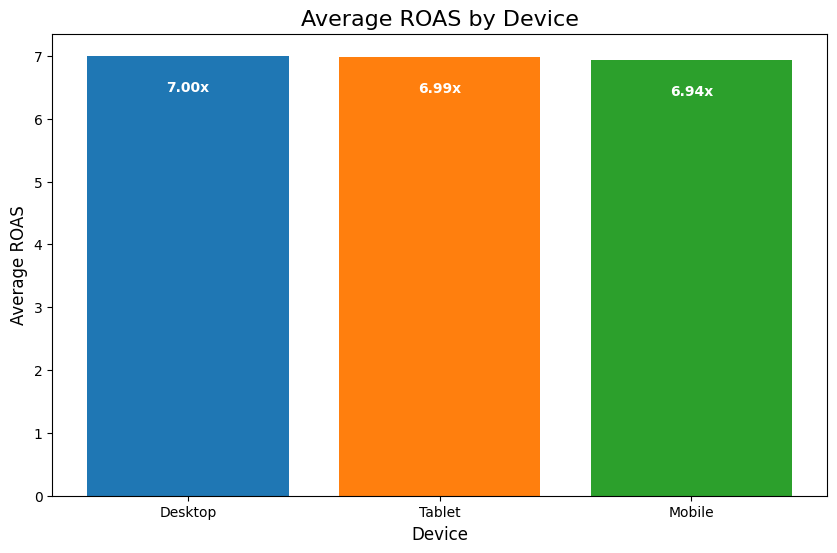

In [200]:
# Visualization 1: ROAS by Device
plt.figure(figsize=(10, 6))
device_perf = df_cleaned.groupby('Device').apply(lambda x: (x['Sale_Amount'].sum() / x['Cost'].sum())).sort_values(ascending=False)
bars = plt.bar(device_perf.index, device_perf.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add labels inside bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 0.5, f'{yval:.2f}x', 
             va='center', ha='center', color='white', fontweight='bold')
plt.title('Average ROAS by Device', fontsize=16)
plt.xlabel('Device', fontsize=12)
plt.ylabel('Average ROAS', fontsize=12)
plt.show()

C:\Users\Dan\AppData\Local\Temp\ipykernel_4532\1514152493.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=keyword_perf.values, y=keyword_perf.index, palette='viridis')


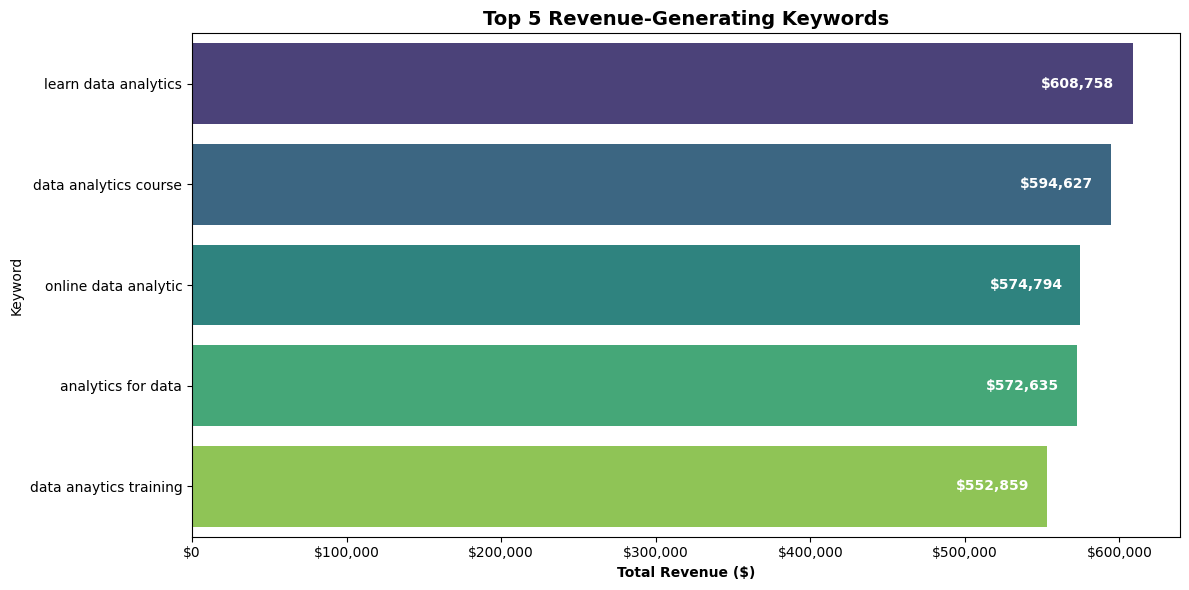

In [201]:
# Visualization 2: Top Keywords by Revenue
# 1. Set the figure size
from matplotlib import ticker

plt.figure(figsize=(12, 6))

# 2. Prepare the data
keyword_perf = df_cleaned.groupby('Keyword')['Sale_Amount'].sum().sort_values(ascending=False).head(5)

# 3. Create the barplot
# Assigning to 'ax' allows us to modify axis formatting easily
ax = sns.barplot(x=keyword_perf.values, y=keyword_perf.index, palette='viridis')

# 4. REVISION: Add thousand separators to the X-axis ticks
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# 5. Add title and labels
plt.title('Top 5 Revenue-Generating Keywords', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontweight='bold')

# 6. Add formatted text labels onto the bars
for index, value in enumerate(keyword_perf.values):
    # Using :,.0f ensures the comma is used as a thousand separator
    plt.text(value * 0.98, index, f'${value:,.0f}', 
             va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

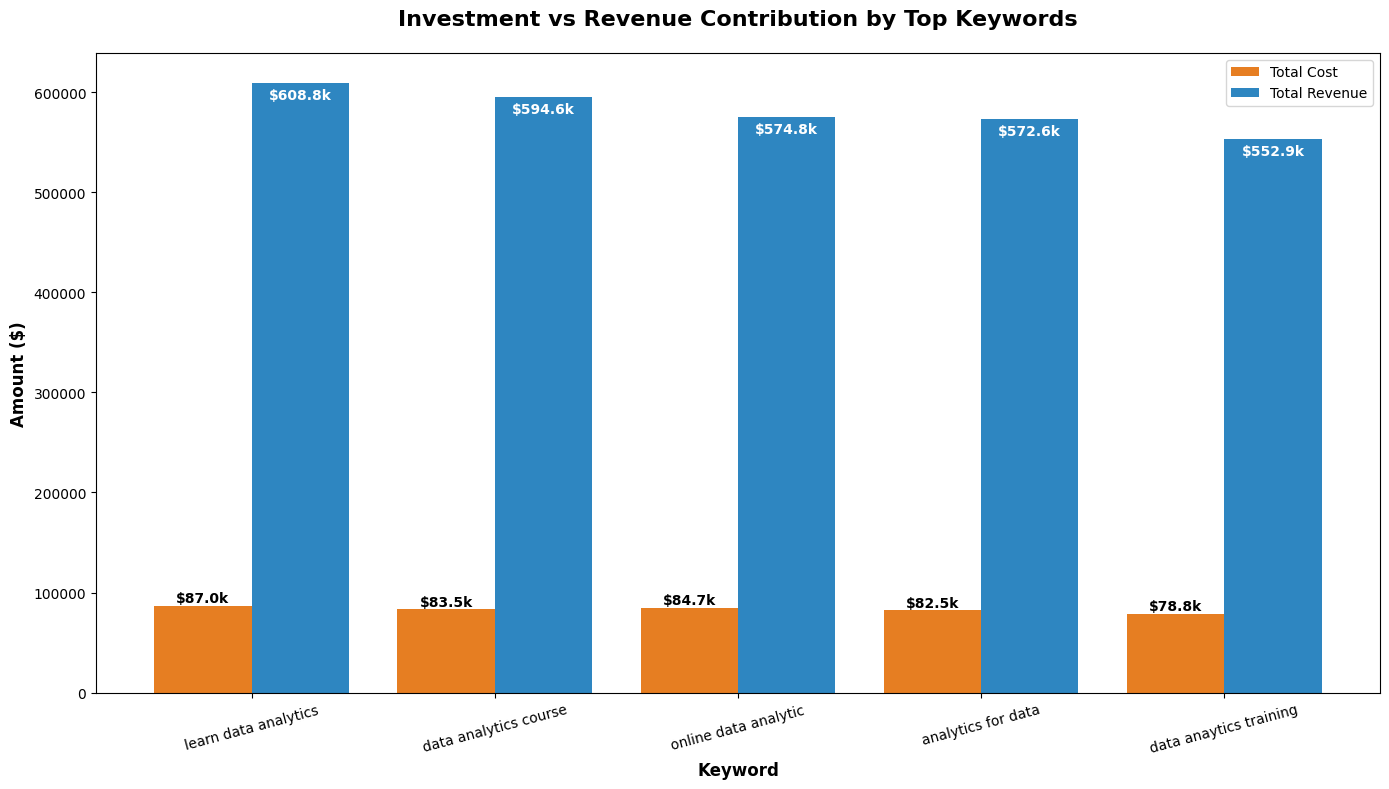

In [ ]:
# Visualization 3: Investment vs Revenue Contribution by Top Keywords   
# Calculate total cost and revenue for top keywords
# 1. Prepare Data
top_keywords = df_cleaned.groupby('Keyword').agg({'Cost': 'sum', 'Sale_Amount': 'sum'}).sort_values(by='Sale_Amount', ascending=False).head(5)
top_keywords = top_keywords.reset_index() # Reset index for easier plotting

# 2. Setup Plot
plt.figure(figsize=(14, 8))
x = np.arange(len(top_keywords['Keyword']))  # Label locations
width = 0.4  # Width of the bars

# 3. Create Side-by-Side (Grouped) Bars
bar1 = plt.bar(x - width/2, top_keywords['Cost'], width, label='Total Cost', color='#E67E22') # Professional Orange
bar2 = plt.bar(x + width/2, top_keywords['Sale_Amount'], width, label='Total Revenue', color='#2E86C1') # Professional Blue

# 4. Styling
plt.title('Investment vs Revenue Contribution by Top Keywords', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Keyword', fontsize=12, fontweight='bold')
plt.ylabel('Amount ($)', fontsize=12, fontweight='bold')
plt.xticks(x, top_keywords['Keyword'], rotation=15)
plt.legend()

# 5. Adding Dynamic Labels (Inside for Revenue, Outside for Cost)
# Add labels for Cost (Orange Bars)
for bar in bar1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'${yval/1000:.1f}k', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Add labels for Revenue (Blue Bars)
for bar in bar2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 5000, f'${yval/1000:.1f}k', 
             ha='center', va='top', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()




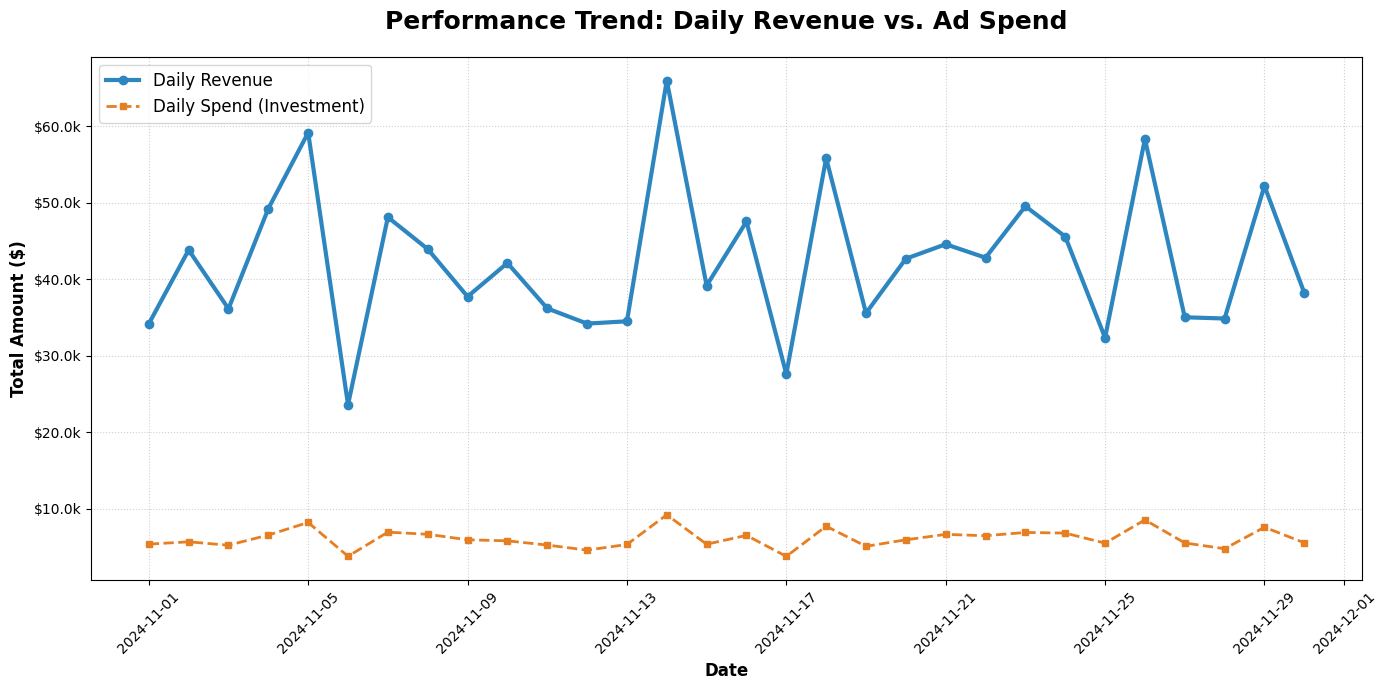

In [203]:
# 2. Prepare Time-Series Data
# Convert Ad_Date to datetime and aggregate by day
from matplotlib.ticker import FuncFormatter


df['Ad_Date'] = pd.to_datetime(df['Ad_Date'], errors='coerce')
trend_df = df.dropna(subset=['Ad_Date']).groupby('Ad_Date').agg({
    'Cost': 'sum',
    'Sale_Amount': 'sum'
}).sort_index()

# 3. Create the Line Chart
plt.figure(figsize=(14, 7))

# Plotting Revenue and Spend
plt.plot(trend_df.index, trend_df['Sale_Amount'], label='Daily Revenue', 
         color='#2E86C1', linewidth=3, marker='o', markersize=6)
plt.plot(trend_df.index, trend_df['Cost'], label='Daily Spend (Investment)', 
         color='#E67E22', linewidth=2, linestyle='--', marker='s', markersize=4)

# 4. Professional Formatting
plt.title('Performance Trend: Daily Revenue vs. Ad Spend', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Total Amount ($)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')

# Formatting Y-axis for clarity (using $k notation)
def currency_k(x, pos):
    return f'${x/1000:.1f}k'
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_k))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_spend_trend.png')